# Meat Futures: Spread & Farm-to-Retail Basis Analysis

**Question:** How efficiently do US meat markets price different animal proteins relative to
each other, and how well do farm-gate (futures) prices transmit to what consumers pay at retail?

**Contracts (CME, continuous front-month, quoted in cents/lb):**

| Ticker | Contract | What it represents |
|---|---|---|
| `LE=F` | Live Cattle | Finished cattle ready for slaughter (~1,300 lb) |
| `GF=F` | Feeder Cattle | Young cattle entering feedlots (~750 lb) — an *input* to live cattle |
| `HE=F` | Lean Hogs | Slaughter-ready hogs (carcass basis) |

There are no exchange-traded futures for chicken, lamb, mutton, or goat — those species are
covered in the companion demand notebook (`02_demand_trends.ipynb`) using FAO consumption and
BLS retail price data.

**Analyses in this notebook:**
1. Price history overview
2. Inter-commodity spreads — the feeder–live cattle spread (a feeding-margin proxy) and the
   cattle/hog ratio (relative protein pricing)
3. Seasonality in each contract
4. Farm-to-retail spread — retail price minus futures price, a basis-style measure of the
   marketing margin and how it has drifted over time
5. Price transmission — how quickly futures moves show up in retail prices

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from data_fetch import fetch_futures, fetch_bls_prices

sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

futures = fetch_futures()          # daily, cents/lb
retail = fetch_bls_prices()        # monthly, $/lb (+ CPI index)

print(f"Futures: {futures.index.min():%Y-%m-%d} to {futures.index.max():%Y-%m-%d}, {len(futures):,} days")
print(f"Retail:  {retail.index.min():%Y-%m} to {retail.index.max():%Y-%m}, {len(retail)} months")
futures.tail()

Futures: 2005-01-03 to 2026-08-10, 5,435 days
Retail:  1997-01 to 2026-06, 353 months


,live_cattle,feeder_cattle,lean_hogs
date,,,
2026-08-04,231.949997,351.200012,97.849998
2026-08-05,234.175003,353.325012,96.599998
2026-08-06,231.225006,348.049988,95.500000
2026-08-07,231.699997,351.649994,95.500000
2026-08-10,226.750000,346.299988,83.599998


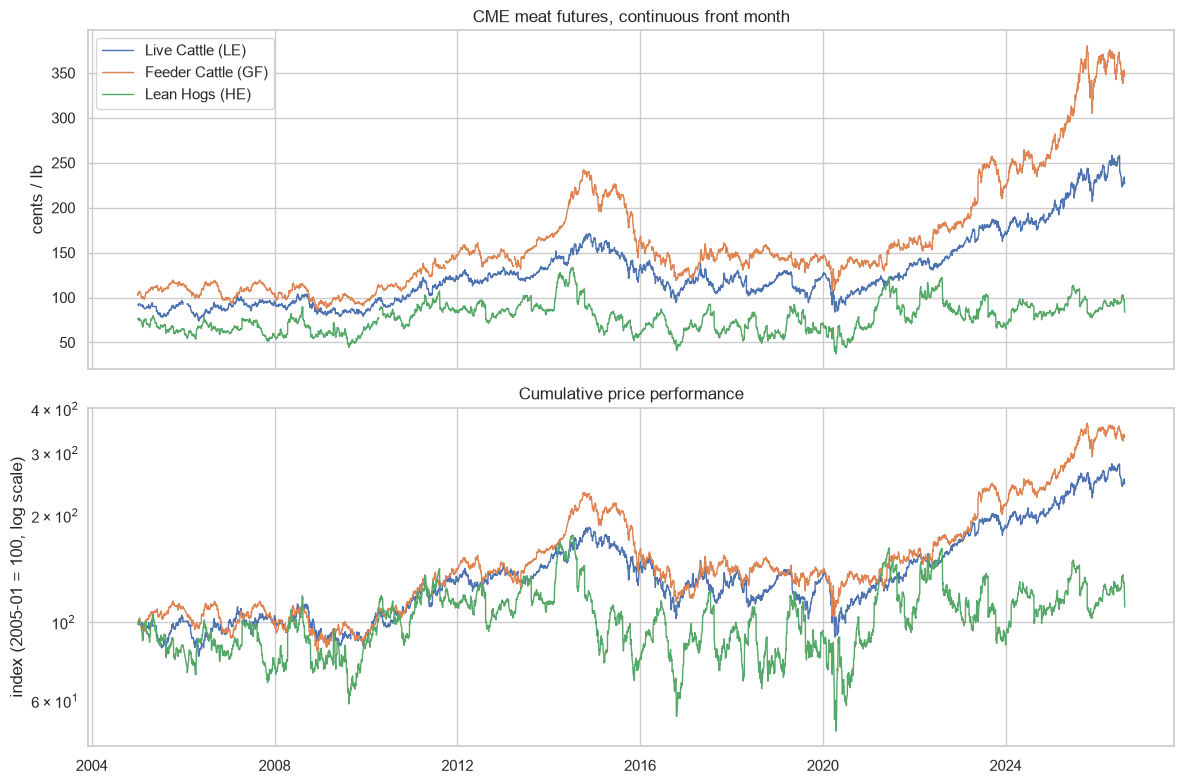

Total price change over sample:
live_cattle      145.8 %
feeder_cattle    232.5 %
lean_hogs         10.4 %
dtype: str


In [2]:
# --- 1. Price history overview -------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

labels = {"live_cattle": "Live Cattle (LE)", "feeder_cattle": "Feeder Cattle (GF)", "lean_hogs": "Lean Hogs (HE)"}
for col in futures.columns:
    axes[0].plot(futures.index, futures[col], label=labels[col], lw=1)
axes[0].set_ylabel("cents / lb")
axes[0].set_title("CME meat futures, continuous front month")
axes[0].legend()

# Indexed to 100 at the start of the common sample, log scale for comparability
common = futures.dropna()
indexed = 100 * common / common.iloc[0]
for col in indexed.columns:
    axes[1].plot(indexed.index, indexed[col], label=labels[col], lw=1)
axes[1].set_yscale("log")
axes[1].set_ylabel(f"index ({common.index[0]:%Y-%m} = 100, log scale)")
axes[1].set_title("Cumulative price performance")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_price_overview.png", dpi=150, bbox_inches="tight")
plt.show()

print("Total price change over sample:")
print(((common.iloc[-1] / common.iloc[0] - 1) * 100).round(1).astype(str) + " %")

## 2. Inter-commodity spreads

**Feeder–live spread (`GF − LE`).** Feeder cattle are the raw material that feedlots buy and
finish into live cattle. When feeders trade at a large premium to live cattle, feedlot margins
are squeezed (expensive input, cheaper output) — a signal of tight calf supply. When the spread
narrows, feeding economics improve. This is a simplified proxy: a full "cattle crush" would also
short corn, the other main input.

**Cattle/hog ratio (`LE ÷ HE`).** Beef and pork compete on the same dinner plate, so their
relative price is mean-reverting over long horizons. A ratio far above its historical average
says beef is expensive relative to pork — which shifts consumer substitution toward pork and,
historically, eventually pulls the ratio back. Persistent deviation from the mean is evidence of
a *structural* shift (e.g. the post-2020 cattle herd contraction) rather than noise.

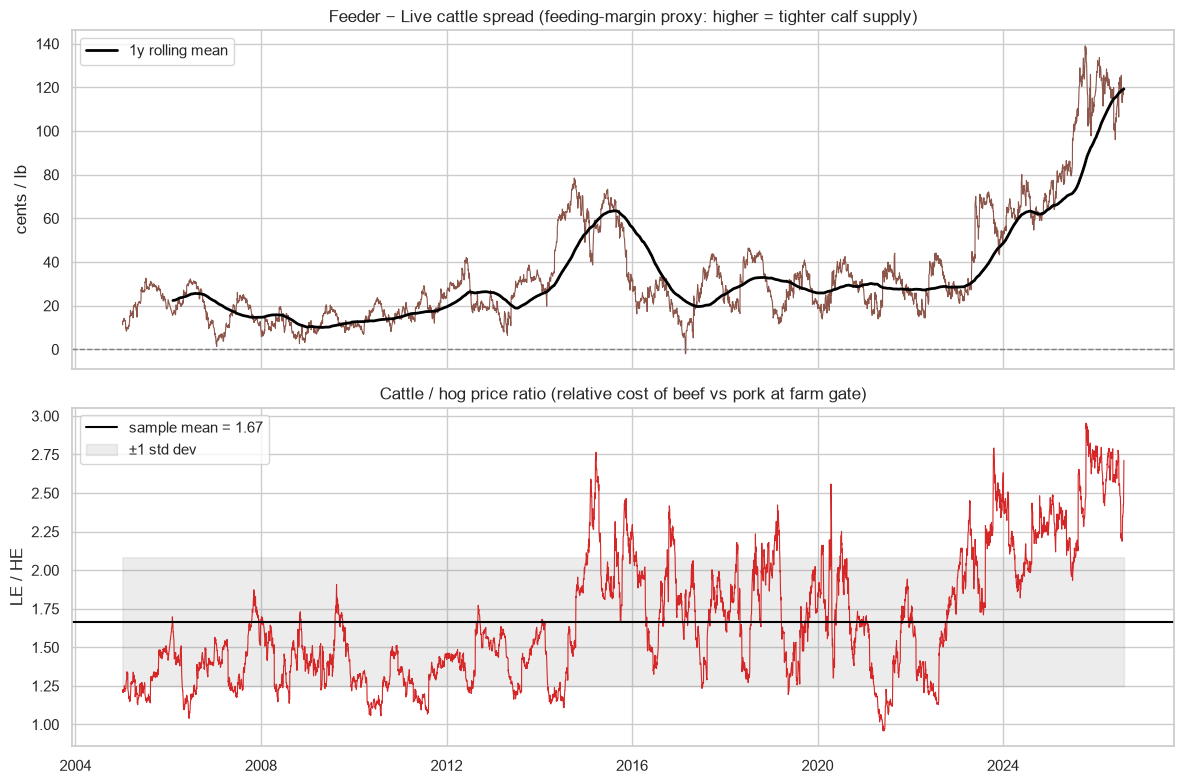

Latest feeder-live spread: 119.5 c/lb (historical mean 34.9)
Latest cattle/hog ratio:  2.71  ->  z-score +2.51 vs 2005-present


In [3]:
# --- 2. Inter-commodity spreads --------------------------------------------
spreads = pd.DataFrame(index=common.index)
spreads["feeder_minus_live"] = common["feeder_cattle"] - common["live_cattle"]
spreads["cattle_hog_ratio"] = common["live_cattle"] / common["lean_hogs"]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
ax.plot(spreads.index, spreads["feeder_minus_live"], lw=0.8, color="tab:brown")
ax.plot(spreads.index, spreads["feeder_minus_live"].rolling(252).mean(), lw=2,
        color="black", label="1y rolling mean")
ax.axhline(0, color="grey", ls="--", lw=1)
ax.set_ylabel("cents / lb")
ax.set_title("Feeder − Live cattle spread (feeding-margin proxy: higher = tighter calf supply)")
ax.legend()

ax = axes[1]
ratio = spreads["cattle_hog_ratio"]
mu, sd = ratio.mean(), ratio.std()
ax.plot(ratio.index, ratio, lw=0.8, color="tab:red")
ax.axhline(mu, color="black", lw=1.5, label=f"sample mean = {mu:.2f}")
ax.fill_between(ratio.index, mu - sd, mu + sd, alpha=0.15, color="grey", label="±1 std dev")
ax.set_ylabel("LE / HE")
ax.set_title("Cattle / hog price ratio (relative cost of beef vs pork at farm gate)")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "02_spreads.png", dpi=150, bbox_inches="tight")
plt.show()

latest = spreads.dropna().iloc[-1]
z = (latest["cattle_hog_ratio"] - mu) / sd
print(f"Latest feeder-live spread: {latest['feeder_minus_live']:.1f} c/lb "
      f"(historical mean {spreads['feeder_minus_live'].mean():.1f})")
print(f"Latest cattle/hog ratio:  {latest['cattle_hog_ratio']:.2f}  ->  z-score {z:+.2f} vs 2005-present")

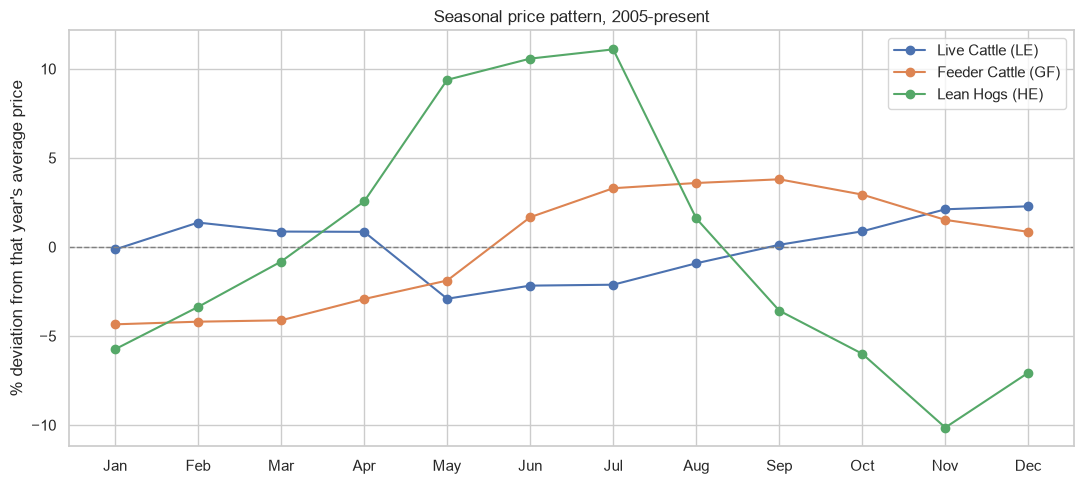

Live Cattle (LE)     strongest: Dec (+2.3%)   weakest: May (-2.9%)
Feeder Cattle (GF)   strongest: Sep (+3.8%)   weakest: Jan (-4.3%)
Lean Hogs (HE)       strongest: Jul (+11.1%)   weakest: Nov (-10.1%)


In [4]:
# --- 3. Seasonality ---------------------------------------------------------
# Average calendar-month deviation from each year's mean price, so every year
# contributes equally regardless of its price level.
monthly = common.resample("MS").mean()
yearly_mean = monthly.groupby(monthly.index.year).transform("mean")
seasonal_dev = (monthly / yearly_mean - 1) * 100
seasonal = seasonal_dev.groupby(seasonal_dev.index.month).mean()

fig, ax = plt.subplots(figsize=(11, 5))
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
for col in seasonal.columns:
    ax.plot(range(1, 13), seasonal[col], marker="o", label=labels[col])
ax.axhline(0, color="grey", ls="--", lw=1)
ax.set_xticks(range(1, 13), month_names)
ax.set_ylabel("% deviation from that year's average price")
ax.set_title("Seasonal price pattern, 2005-present")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "03_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()

for col in seasonal.columns:
    hi, lo = seasonal[col].idxmax(), seasonal[col].idxmin()
    print(f"{labels[col]:<20} strongest: {month_names[hi-1]} ({seasonal[col][hi]:+.1f}%)   "
          f"weakest: {month_names[lo-1]} ({seasonal[col][lo]:+.1f}%)")

## 4. Farm-to-retail spread (basis-style margin)

Classic *basis* is a local cash price minus the futures price. Public cash-market data
(USDA AMS) requires an API key, so here we compute the closely-related **farm-to-retail
spread**: the BLS average retail price of a cut minus the front-month futures price, both in
$/lb. This spread contains everything between the animal and the shelf — slaughter, processing,
packaging, distribution, and retailer margin.

Pairs analysed (retail cut vs underlying contract):

- Ground beef vs Live Cattle
- Bacon and boneless pork chops vs Lean Hogs

Two caveats worth stating (and good interview talking points): a retail pound of meat comes
from more than a pound of live animal (dressing/cutting yield), and futures are national while
BLS prices are a city-average — so the *level* of the spread is less meaningful than its
*trend and volatility*. We also deflate by CPI to separate real margin expansion from general
inflation.

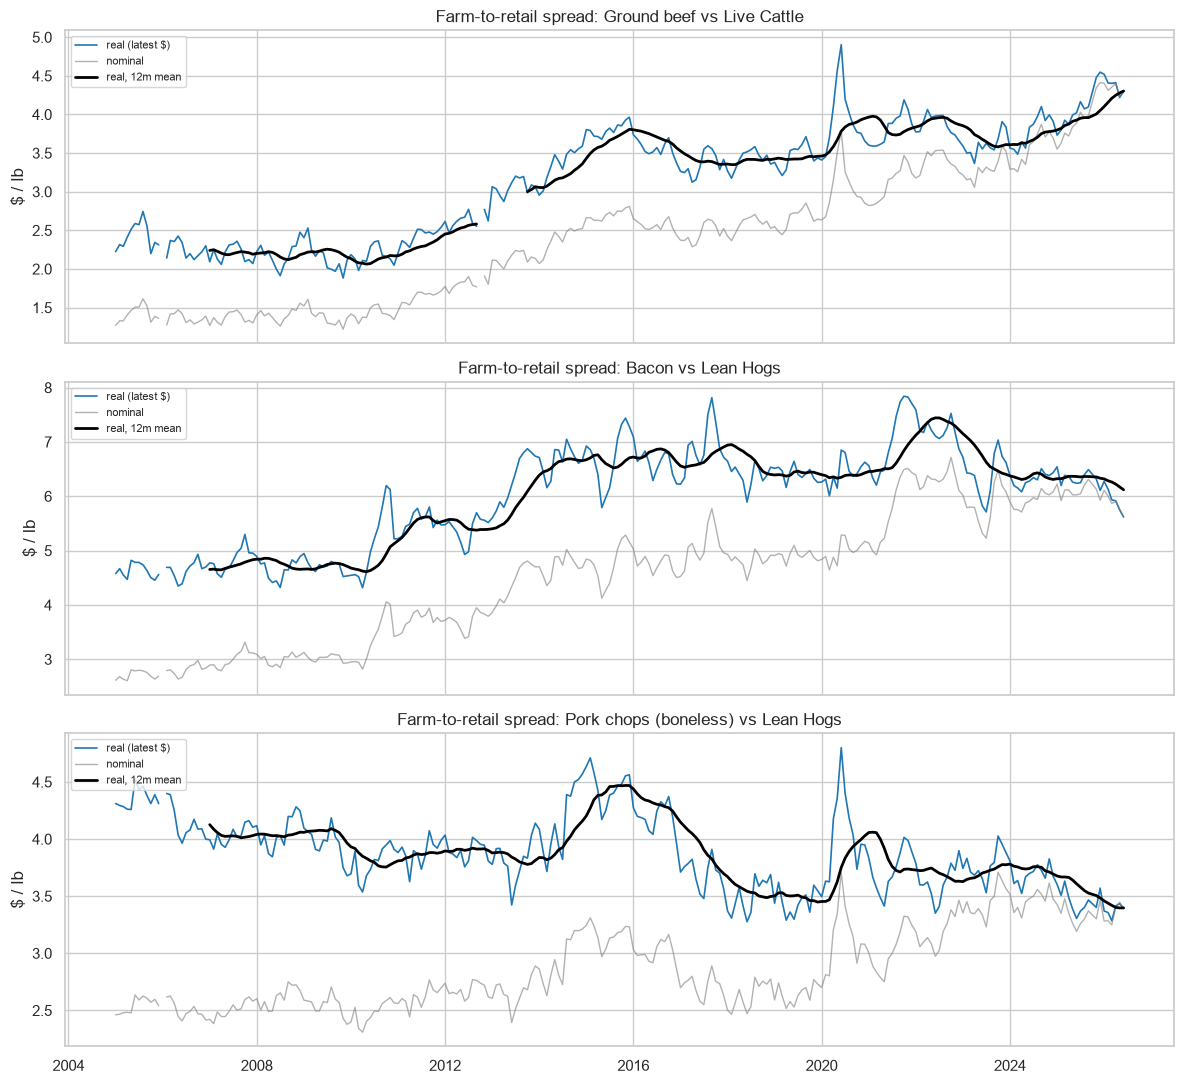

Real spread, first 5 years vs latest 5 years of sample:
  Ground beef vs Live Cattle             $2.24 -> $3.90  (+74%)
  Bacon vs Lean Hogs                     $4.69 -> $6.61  (+41%)
  Pork chops (boneless) vs Lean Hogs     $4.10 -> $3.64  (-11%)


In [5]:
# --- 4. Farm-to-retail spread ----------------------------------------------
fut_monthly = common.resample("MS").mean() / 100          # cents/lb -> $/lb
panel = retail.join(fut_monthly, how="inner").dropna(subset=["cpi_all_items"])

# Deflate everything to latest-month dollars
deflator = panel["cpi_all_items"].iloc[-1] / panel["cpi_all_items"]

pairs = {
    "Ground beef vs Live Cattle": ("ground_beef_lb", "live_cattle"),
    "Bacon vs Lean Hogs": ("bacon_lb", "lean_hogs"),
    "Pork chops (boneless) vs Lean Hogs": ("pork_chops_boneless_lb", "lean_hogs"),
}

fig, axes = plt.subplots(len(pairs), 1, figsize=(12, 11), sharex=True)
summary = {}
for ax, (name, (r_col, f_col)) in zip(axes, pairs.items()):
    nominal = panel[r_col] - panel[f_col]
    real = nominal * deflator
    ax.plot(real.index, real, lw=1.2, color="tab:blue", label="real (latest $)")
    ax.plot(nominal.index, nominal, lw=1, color="tab:grey", alpha=0.6, label="nominal")
    ax.plot(real.index, real.rolling(12).mean(), lw=2, color="black", label="real, 12m mean")
    ax.set_title(f"Farm-to-retail spread: {name}")
    ax.set_ylabel("$ / lb")
    ax.legend(loc="upper left", fontsize=8)
    first5, last5 = real.dropna().iloc[:60].mean(), real.dropna().iloc[-60:].mean()
    summary[name] = (first5, last5)

plt.tight_layout()
plt.savefig(FIG_DIR / "04_farm_to_retail_spread.png", dpi=150, bbox_inches="tight")
plt.show()

print("Real spread, first 5 years vs latest 5 years of sample:")
for name, (a, b) in summary.items():
    print(f"  {name:<38} ${a:.2f} -> ${b:.2f}  ({(b/a-1)*100:+.0f}%)")

Ground beef vs Live Cattle             peak correlation 0.23 at lag 5 month(s)
Bacon vs Lean Hogs                     peak correlation 0.38 at lag 2 month(s)
Pork chops (boneless) vs Lean Hogs     peak correlation 0.26 at lag 1 month(s)


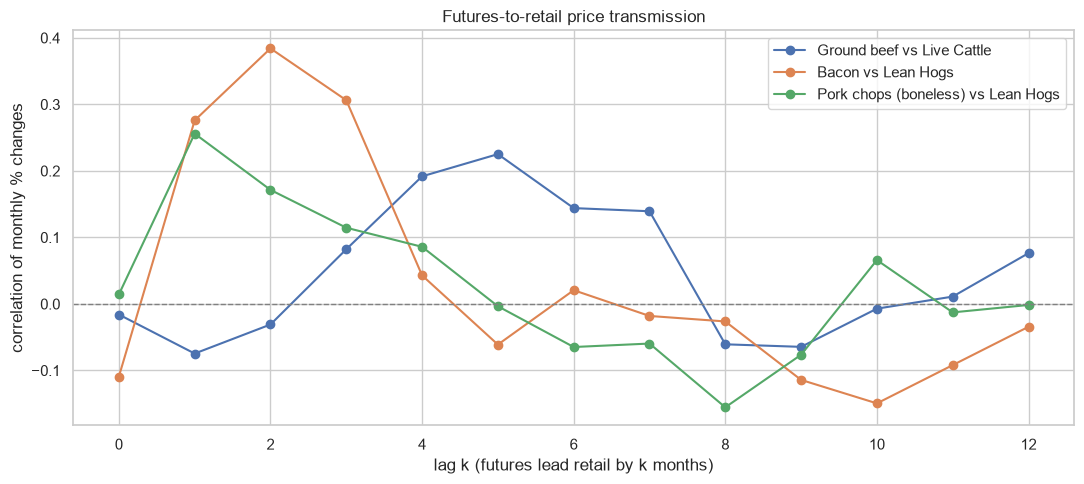

In [6]:
# --- 5. Price transmission: do futures lead retail? -------------------------
# Cross-correlation between monthly futures returns and retail price changes
# at various lags. Positive lag k = futures move k months BEFORE retail.
def cross_corr(fut_ret, ret_ret, max_lag=12):
    return pd.Series(
        {k: fut_ret.shift(k).corr(ret_ret) for k in range(0, max_lag + 1)}
    )

fig, ax = plt.subplots(figsize=(11, 5))
for name, (r_col, f_col) in pairs.items():
    fut_ret = panel[f_col].pct_change()
    ret_ret = panel[r_col].pct_change()
    cc = cross_corr(fut_ret, ret_ret)
    ax.plot(cc.index, cc.values, marker="o", label=name)
    peak = cc.idxmax()
    print(f"{name:<38} peak correlation {cc[peak]:.2f} at lag {peak} month(s)")

ax.axhline(0, color="grey", ls="--", lw=1)
ax.set_xlabel("lag k (futures lead retail by k months)")
ax.set_ylabel("correlation of monthly % changes")
ax.set_title("Futures-to-retail price transmission")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "05_price_transmission.png", dpi=150, bbox_inches="tight")
plt.show()

## Takeaways

1. **Cattle and hogs have completely diverged since 2005.** Feeder cattle are up ~230% and live
   cattle ~145%, while lean hogs gained only ~10%. Hog production scales quickly (large litters,
   ~6-month cycle); the cattle cycle takes years to rebuild, and the US herd contraction that
   began around 2020 shows up directly in these prices.

2. **The feeder–live spread is at historic extremes** (~120 ¢/lb vs a ~35 ¢/lb long-run mean),
   meaning calves are scarce and expensive relative to finished cattle — feedlot margins are
   squeezed and herd rebuilding hasn't arrived yet. This is the strongest single signal in the
   dataset that beef supply will stay tight for years.

3. **Beef is ~2.5 standard deviations expensive relative to pork** (cattle/hog ratio z ≈ +2.5).
   If history is a guide, this favors consumer substitution toward pork and poultry — a supply-side
   tailwind for demand of the cheaper proteins.

4. **Seasonality is real and intuitive:** lean hogs peak in July (+11%, grilling season demand
   against tight summer supply) and bottom in November (−10%, peak slaughter); feeders peak in
   September when feedlots restock.

5. **The farm-to-retail spread has widened dramatically in real terms for beef** (+74% for
   ground beef vs live cattle over the sample) and bacon (+41%), i.e. an increasing share of the
   consumer's dollar goes to processing/retail rather than the producer — a market-efficiency
   finding consistent with documented consolidation in meatpacking.

6. **Price transmission is slow and asymmetric by species:** futures lead retail by ~2 months
   for pork products but ~5 months for ground beef, with modest correlations (0.2–0.4) —
   retail prices are sticky relative to the farm gate.